# 98. BL Baseline — 20년 백테스트 (2006~2025)

99_baseline과 동일한 구조이나 **TRAIN_WINDOW=24개월**로 단축하여
2006년부터 예측 기간에 포함 (금융위기 2008~2009 포함).

| 항목 | 98_baseline | 99_baseline |
|------|------------|-------------|
| TRAIN_WINDOW | **24개월** | 60개월 |
| 예측 시작 | **2006-01** | 2009-01 |
| 예측 기간 | **~20년** | ~17년 |
| 금융위기 포함 | **O** | O |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
import platform
from pathlib import Path
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize
from bl_utils import *  # 공통 BL/Q/성과 유틸리티

warnings.filterwarnings('ignore')
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'
OUT_DIR  = BASE_DIR / 'outputs' / '98_2006_baseline'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 파라미터 ────────────────────────────────────────────────
TRAIN_WINDOW = 24    # 24개월 워밍업(2004-01~) → 2006-01부터 예측 (20년)
TAU          = 0.1
PCT_GROUP    = 0.30
START_PRED   = '2006-01-01'  # 20년 백테스트 (2006~2025)

# Q: 문헌 기반 장기 저위험 프리미엄 (Ang et al. 2006, Baker et al. 2011)
Q_FIXED = 0.003  # 월 0.3% = 연 3.6%

# ── 데이터 로드 ──────────────────────────────────────────────
panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv', parse_dates=['date'])
panel = panel.set_index(['date', 'ticker'])

all_dates  = panel.index.get_level_values('date').unique().sort_values()
pred_dates = all_dates[all_dates >= START_PRED]

print(f'패널: {panel.shape}')
print(f'예측 기간: {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')
print(f'Q_FIXED = {Q_FIXED}  (월 {Q_FIXED*100:.1f}%  |  연 {Q_FIXED*12*100:.1f}%)')

패널: (108135, 11)
예측 기간: 2006-01-31 ~ 2025-12-31 (240개월)
Q_FIXED = 0.003  (월 0.3%  |  연 3.6%)


In [3]:
# ── Walk-forward ──────────────────────────────────────────────
ret_pivot  = panel['ret_1m'].unstack('ticker')
spy_series = panel['spy_ret'].groupby(level='date').first()
rf_series  = panel['rf_1m'].groupby(level='date').first()
bl_returns, capm_returns, spy_returns, error_log = [], [], [], []
print(f'Walk-forward: {pred_dates[0].date()} ~ {pred_dates[-1].date()}')
for i, pred_date in enumerate(pred_dates):
    if (i + 1) % 12 == 0:
        print(f'  {pred_date.date()} ({i+1}/{len(pred_dates)})')
    try:
        # pred_date 기준 피처로 포트폴리오 구성 → 다음달 수익률 적용
        month_df = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'log_mcap', 'ret_1m'])
        if len(month_df) < 30:
            continue
        universe = month_df.index.tolist()
        idx         = all_dates.get_loc(pred_date)
        train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]
        thresh    = int(len(train_dates) * 0.7)
        ret_slice = (ret_pivot.reindex(index=train_dates, columns=universe)
                              .dropna(axis=1, thresh=thresh)
                              .fillna(0))
        valid_tix = ret_slice.columns.tolist()
        if len(valid_tix) < 20:
            continue
        month_df = month_df.reindex(valid_tix)
        Sigma    = compute_sigma(ret_slice)
        mcap  = np.exp(month_df['log_mcap'])
        w_mkt = (mcap / mcap.sum()).reindex(valid_tix).fillna(0)
        spy_s      = spy_series.reindex(train_dates)
        rf_s       = rf_series.reindex(train_dates)
        spy_excess = (spy_s - rf_s).mean()
        sigma2_mkt = spy_s.var()
        pi, lam = compute_pi(Sigma, w_mkt, spy_excess, sigma2_mkt)
        P = build_P(month_df['vol_21d'], mcap, pct=PCT_GROUP)
        P = P.reindex(valid_tix).fillna(0)
        omega = compute_omega(P, Sigma, TAU)
        mu_BL = black_litterman(pi, Sigma, P, Q_FIXED, omega, TAU)
        w_bl   = optimize_portfolio(mu_BL, Sigma, lam)
        w_capm = optimize_portfolio(pi,    Sigma, lam)
        # ── 다음달 수익률 적용 (look-ahead bias 방지) ──────────
        next_date  = all_dates[idx + 1] if idx + 1 < len(all_dates) else None
        actual_ret = (ret_pivot.loc[next_date].reindex(valid_tix).fillna(0)
                            if next_date is not None
                            else month_df['fwd_ret_1m'].reindex(valid_tix).fillna(0))
        r_spy      = float(spy_series.get(next_date, np.nan)) if next_date is not None else np.nan
        bl_returns.append(  {'date': pred_date, 'ret': float(w_bl   @ actual_ret)})
        capm_returns.append({'date': pred_date, 'ret': float(w_capm @ actual_ret)})
        spy_returns.append( {'date': pred_date, 'ret': r_spy})
    except Exception as e:
        error_log.append({'date': pred_date, 'error': str(e)})
        if len(error_log) <= 3:
            print(f'  [에러] {pred_date.date()}: {e}')
print(f'\n성공: {len(bl_returns)}개월 / {len(pred_dates)}개월')
print(f'에러: {len(error_log)}개월')
bl_ret   = pd.DataFrame(bl_returns).set_index('date')['ret']
capm_ret = pd.DataFrame(capm_returns).set_index('date')['ret']
spy_ret  = pd.DataFrame(spy_returns).set_index('date')['ret']
print('DataFrame 생성 완료')


Walk-forward: 2006-01-31 ~ 2025-12-31
  2006-12-31 (12/240)
  2007-12-31 (24/240)
  2008-12-31 (36/240)
  2009-12-31 (48/240)
  2010-12-31 (60/240)
  2011-12-31 (72/240)
  2012-12-31 (84/240)
  2013-12-31 (96/240)
  2014-12-31 (108/240)
  2015-12-31 (120/240)
  2016-12-31 (132/240)
  2017-12-31 (144/240)
  2018-12-31 (156/240)
  2019-12-31 (168/240)
  2020-12-31 (180/240)
  2021-12-31 (192/240)
  2022-12-31 (204/240)
  2023-12-31 (216/240)
  2024-12-31 (228/240)
  2025-12-31 (240/240)

성공: 240개월 / 240개월
에러: 0개월
DataFrame 생성 완료


In [4]:
# ── 성과 분석 ─────────────────────────────────────────────────
ANN        = np.sqrt(12)
rf_monthly = rf_series.reindex(bl_ret.index).fillna(0)

print('=' * 55)
print(f'포트폴리오 성과 비교 ({pred_dates[0].date()} ~ {pred_dates[-1].date()})')
print('=' * 55)
stats = []
for ret, label in [(bl_ret,'BL Baseline'), (capm_ret,'CAPM 균형'), (spy_ret,'S&P 500')]:
    stats.append(performance(ret, rf_monthly, label))
    print()

포트폴리오 성과 비교 (2006-01-31 ~ 2025-12-31)
[BL Baseline]
  연환산 수익률: 9.77%
  연환산 변동성: 13.31%
  Sharpe Ratio:  0.612
  누적 수익률:   485.53%
  MDD:           -55.97%

[CAPM 균형]
  연환산 수익률: 11.33%
  연환산 변동성: 17.38%
  Sharpe Ratio:  0.559
  누적 수익률:   601.64%
  MDD:           -60.90%

[S&P 500]
  연환산 수익률: 11.47%
  연환산 변동성: 15.09%
  Sharpe Ratio:  0.655
  누적 수익률:   nan%
  MDD:           -50.78%



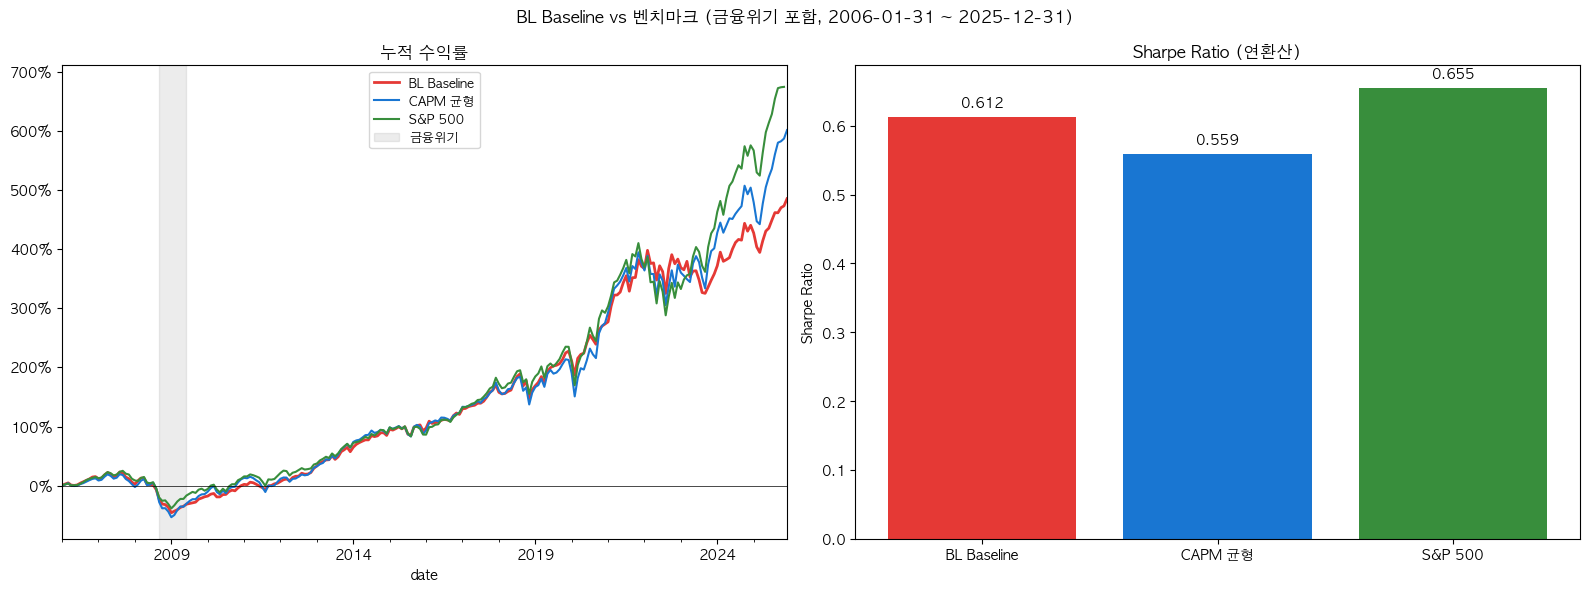

저장 완료


In [5]:
# ── 시각화 ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'BL Baseline vs 벤치마크 (금융위기 포함, {pred_dates[0].date()} ~ {pred_dates[-1].date()})',
             fontsize=12, fontweight='bold')

ax = axes[0]
for ret, label, color, lw in [
    (bl_ret,   'BL Baseline', '#E53935', 2.0),
    (capm_ret, 'CAPM 균형',   '#1976D2', 1.5),
    (spy_ret,  'S&P 500',     '#388E3C', 1.5),
]:
    cum = (1 + ret).cumprod() - 1
    cum.plot(ax=ax, label=label, color=color, linewidth=lw)

# 금융위기 구간 음영
ax.axvspan(pd.Timestamp('2008-09-01'), pd.Timestamp('2009-06-30'),
           alpha=0.15, color='gray', label='금융위기')
ax.set_title('누적 수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=9)
ax.axhline(0, color='black', linewidth=0.5)

ax = axes[1]
labels  = [s['label']  for s in stats]
sharpes = [s['sharpe'] for s in stats]
colors  = ['#E53935', '#1976D2', '#388E3C']
bars    = ax.bar(labels, sharpes, color=colors)
ax.set_title('Sharpe Ratio (연환산)')
ax.set_ylabel('Sharpe Ratio')
ax.axhline(0, color='black', linewidth=0.5)
for bar, val in zip(bars, sharpes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR / 'bl_2006_performance.png', dpi=150, bbox_inches='tight')
plt.show()

result_df = pd.DataFrame({'bl': bl_ret, 'capm': capm_ret, 'spy': spy_ret})
result_df.to_csv(DATA_DIR / 'bl_2006_returns.csv')
print('저장 완료')